# Milestone 2

In [2]:
import sys
sys.path.insert(0, "..")
import ccs_eeg_utils
from mne_bids import (BIDSPath, read_raw_bids)
import mne

bids_root = "../MNE-sample-data/ds006761"
subject_id = "01"

#print_dir_tree(bids_root, max_depth=4)

bids_path = BIDSPath(subject=subject_id, task="RPS",
                     datatype='eeg', suffix='eeg',
                     root=bids_root)

# read the file
raw = read_raw_bids(bids_path)
# fix the annotations readin
ccs_eeg_utils.read_annotations_core(bids_path,raw)


Extracting BDF parameters from ..\MNE-sample-data\ds006761\sub-01\eeg\sub-01_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading events from ..\MNE-sample-data\ds006761\sub-01\eeg\sub-01_task-RPS_events.tsv.


C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6380\3105469879.py:17: RuntimeWarning: Did not find any channels.tsv associated with sub-01_task-RPS.

The search_str was "..\MNE-sample-data\ds006761\sub-01\**\eeg\sub-01*channels.tsv"
  raw = read_raw_bids(bids_path)
C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6380\3105469879.py:17: RuntimeWarning: Unable to map the following column(s) to to MNE:
date: 9/11/2021
player1_age: 25
player1_gender: F
player1_handedness: R
player1_pre_processing_channels_fixed: 
player2_age: 35
player2_gender: M
player2_handedness: R
player2_pre_processing_channels_fixed: T8
  raw = read_raw_bids(bids_path)


In [3]:
eeg_channels = [ch for ch in raw.ch_names]
eeg_channels

['1-A1',
 '1-A2',
 '1-A3',
 '1-A4',
 '1-A5',
 '1-A6',
 '1-A7',
 '1-A8',
 '1-A9',
 '1-A10',
 '1-A11',
 '1-A12',
 '1-A13',
 '1-A14',
 '1-A15',
 '1-A16',
 '1-A17',
 '1-A18',
 '1-A19',
 '1-A20',
 '1-A21',
 '1-A22',
 '1-A23',
 '1-A24',
 '1-A25',
 '1-A26',
 '1-A27',
 '1-A28',
 '1-A29',
 '1-A30',
 '1-A31',
 '1-A32',
 '1-B1',
 '1-B2',
 '1-B3',
 '1-B4',
 '1-B5',
 '1-B6',
 '1-B7',
 '1-B8',
 '1-B9',
 '1-B10',
 '1-B11',
 '1-B12',
 '1-B13',
 '1-B14',
 '1-B15',
 '1-B16',
 '1-B17',
 '1-B18',
 '1-B19',
 '1-B20',
 '1-B21',
 '1-B22',
 '1-B23',
 '1-B24',
 '1-B25',
 '1-B26',
 '1-B27',
 '1-B28',
 '1-B29',
 '1-B30',
 '1-B31',
 '1-B32',
 '1-GSR1',
 '1-GSR2',
 '1-Erg1',
 '1-Erg2',
 '1-Resp',
 '1-Plet',
 '1-Temp',
 '2-A1',
 '2-A2',
 '2-A3',
 '2-A4',
 '2-A5',
 '2-A6',
 '2-A7',
 '2-A8',
 '2-A9',
 '2-A10',
 '2-A11',
 '2-A12',
 '2-A13',
 '2-A14',
 '2-A15',
 '2-A16',
 '2-A17',
 '2-A18',
 '2-A19',
 '2-A20',
 '2-A21',
 '2-A22',
 '2-A23',
 '2-A24',
 '2-A25',
 '2-A26',
 '2-A27',
 '2-A28',
 '2-A29',
 '2-A30',
 '2-A31',


In [4]:
# --- 1. Kanaltypen setzen ---
eeg_channels = [ch for ch in raw.ch_names if (ch.startswith("1-A") or ch.startswith("1-B") or
                                              ch.startswith("2-A") or ch.startswith("2-B"))]
eog_channels = ['1-Erg1', '1-Erg2', '2-Erg1', '2-Erg2']
resp_channels = ['1-Resp', '2-Resp']
bio_channels = ['1-Plet', '2-Plet']
temp_channels = ['1-Temp', '2-Temp']
stim_channels = ['Status']

raw.set_channel_types({ch: 'eeg' for ch in eeg_channels})
raw.set_channel_types({ch: 'eog' for ch in eog_channels})
raw.set_channel_types({ch: 'resp' for ch in resp_channels})
raw.set_channel_types({ch: 'bio' for ch in bio_channels})
raw.set_channel_types({ch: 'temperature' for ch in temp_channels})
raw.set_channel_types({ch: 'stim' for ch in stim_channels})

C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6380\692441371.py:14: RuntimeWarning: The unit for channel(s) 1-Temp, 2-Temp has changed from V to C.
  raw.set_channel_types({ch: 'temperature' for ch in temp_channels})
C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6380\692441371.py:15: RuntimeWarning: The unit for channel(s) Status has changed from NA to V.
  raw.set_channel_types({ch: 'stim' for ch in stim_channels})


<RawBDF | sub-01_task-RPS_eeg.bdf, 143 x 7514112 (3669.0 s), ~113 KiB, data not loaded>

In [5]:
%matplotlib ipympl
mne.viz.set_browser_backend('matplotlib')

Using matplotlib as 2D backend.


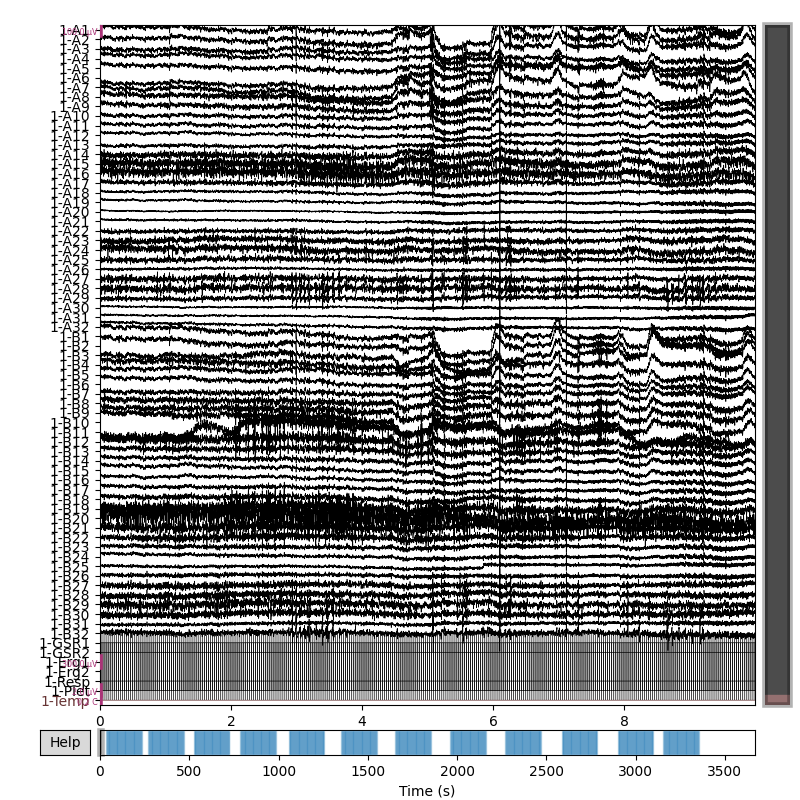

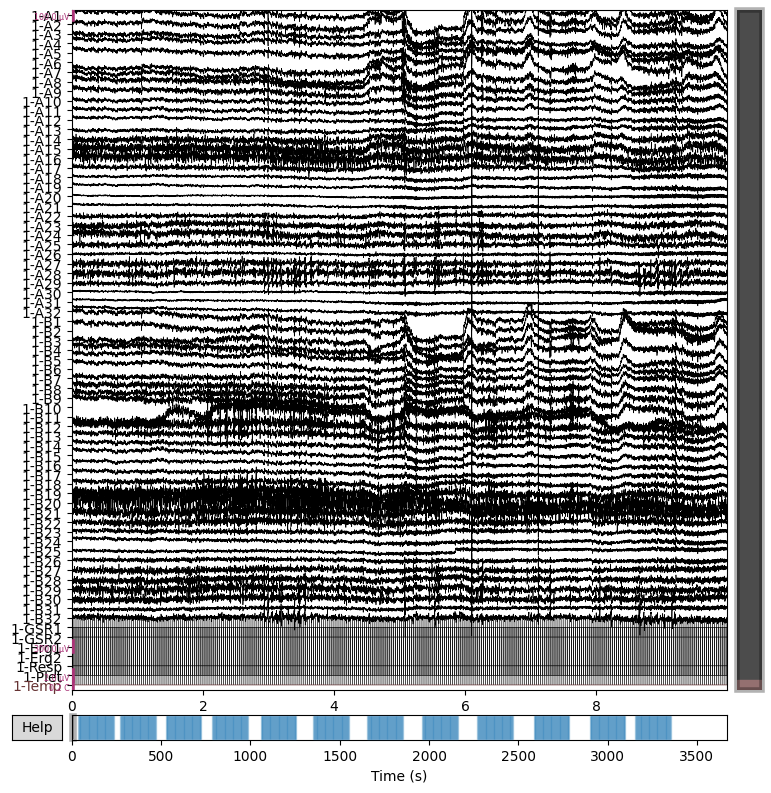

In [6]:
person1_channels = [ch for ch in raw.ch_names if ch.startswith("1-")]

raw.plot(
    picks=person1_channels,
    scalings={'eeg': 50e-6},
    block=True,            # blockiert Jupyter, zeigt ganze Figur
    show_options=False,    # keine Overlay-Menüs
    n_channels=len(person1_channels),  # alle Kanäle gleichzeitig

)


In [ ]:
# Test cell - should complete instantly
print("Cell started")
import numpy as np
print("numpy imported")
x = [1, 2, 3]
print(f"Done: {x}")